In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


from yellowbrick.cluster import KElbowVisualizer

In [2]:
df=pd.read_csv('customer_segmentation.csv')

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [4]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [5]:
df.shape

(2240, 29)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
df.isna().sum().sum()

np.int64(24)

In [8]:
df.dropna(inplace=True)

In [9]:
df.isna().sum().sum()

np.int64(0)

In [10]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0,2216.0,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.009477,3.0,11.0,0.150271
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.096907,0.0,0.0,0.357417
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [11]:
df["Education"].value_counts()

Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64

In [12]:
df["Marital_Status"].value_counts()

Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [13]:
df["Dt_Customer"]= pd.to_datetime(df["Dt_Customer"],dayfirst = True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2216 non-null   i

In [15]:
df["Age"] = 2025 - df["Year_Birth"]

In [16]:
df["Age"]

0       68
1       71
2       60
3       41
4       44
        ..
2235    58
2236    79
2237    44
2238    69
2239    71
Name: Age, Length: 2216, dtype: int64

In [17]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,0,3,11,1,68
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,0,3,11,0,71
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,0,3,11,0,60
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,0,3,11,0,41
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,0,3,11,0,44


In [18]:
df["Total_Children"] = df["Kidhome"]+ df["Teenhome"]

In [19]:
df["Total_Children"]

0       0
1       2
2       0
3       1
4       1
       ..
2235    1
2236    3
2237    0
2238    1
2239    2
Name: Total_Children, Length: 2216, dtype: int64

In [20]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children'],
      dtype='object')

In [21]:
spend_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

In [22]:
df["Total_Spending"] = df[spend_cols].sum(axis = 1)

In [23]:
df[["Total_Spending"]]

,Total_Spending
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


In [24]:
df["Customer_Since"] = (pd.Timestamp("today")-df["Dt_Customer"]).dt.days

In [25]:
df["Customer_Since"]

0       4992
1       4442
2       4641
3       4468
4       4490
        ... 
2235    4710
2236    4348
2237    4484
2238    4485
2239    4951
Name: Customer_Since, Length: 2216, dtype: int64

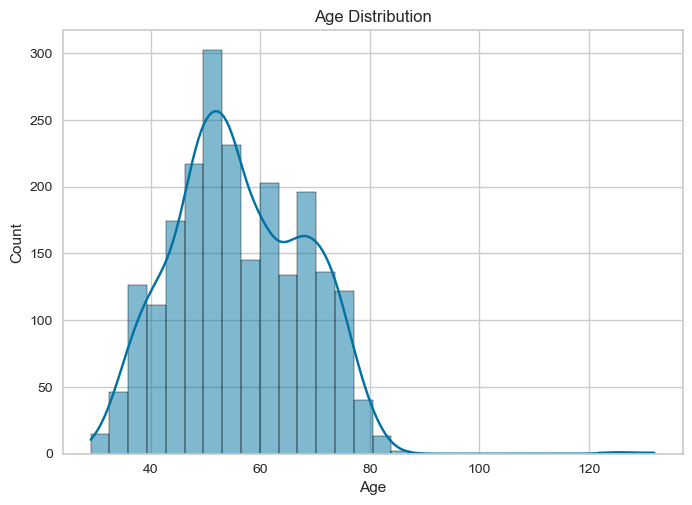

In [26]:
sns.histplot(df["Age"], bins= 30, kde=True)
plt.title("Age Distribution")
plt.show()

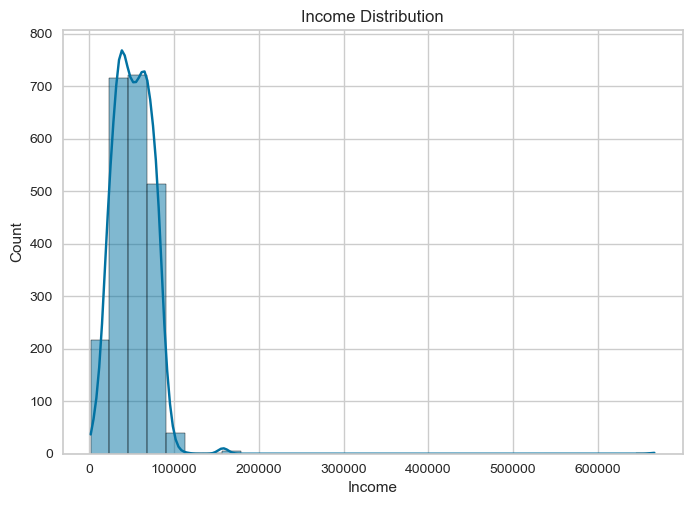

In [27]:
sns.histplot(df["Income"], bins= 30, kde=True)
plt.title("Income Distribution")
plt.show()

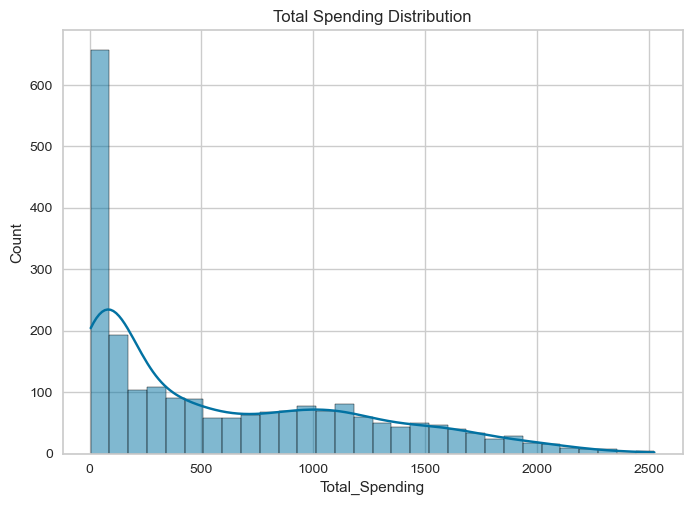

In [28]:
sns.histplot(df["Total_Spending"], bins= 30, kde=True)
plt.title("Total Spending Distribution")
plt.show()

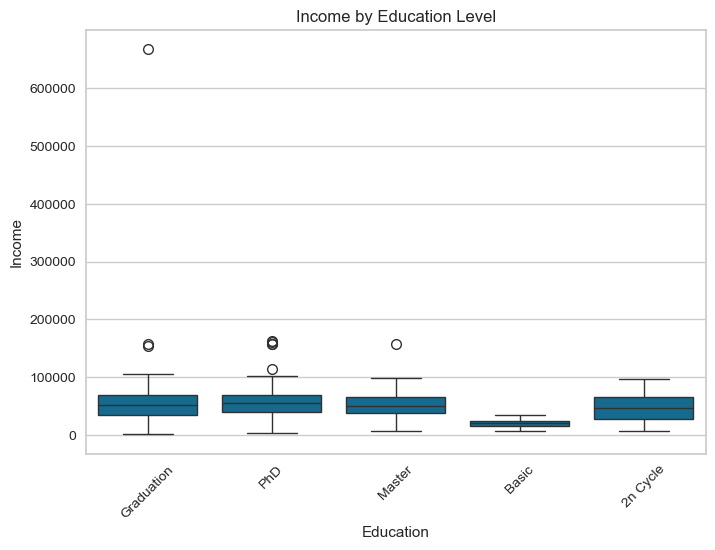

In [29]:
sns.boxplot(x= "Education", y= "Income", data = df)
plt.xticks(rotation = 45)
plt.title("Income by Education Level")
plt.show()

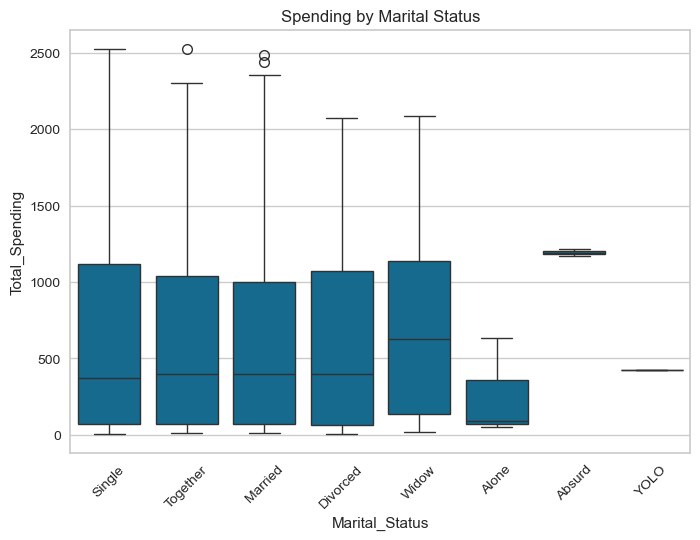

In [30]:
sns.boxplot(x= "Marital_Status", y= "Total_Spending", data = df)
plt.xticks(rotation = 45)
plt.title("Spending by Marital Status")
plt.show()

In [31]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since'],
      dtype='object')

In [32]:
corr = df [["Income","Age","Recency","Total_Spending","NumWebPurchases","NumStorePurchases"]].corr()

In [33]:
corr

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.667576,0.387878,0.529362
Age,0.161791,1.000000,0.016295,0.113487,0.153051,0.127891
Recency,-0.003970,0.016295,1.000000,0.020066,-0.005641,-0.000434
Total_Spending,0.667576,0.113487,0.020066,1.000000,0.528973,0.675181
NumWebPurchases,0.387878,0.153051,-0.005641,0.528973,1.000000,0.516240
NumStorePurchases,0.529362,0.127891,-0.000434,0.675181,0.516240,1.000000


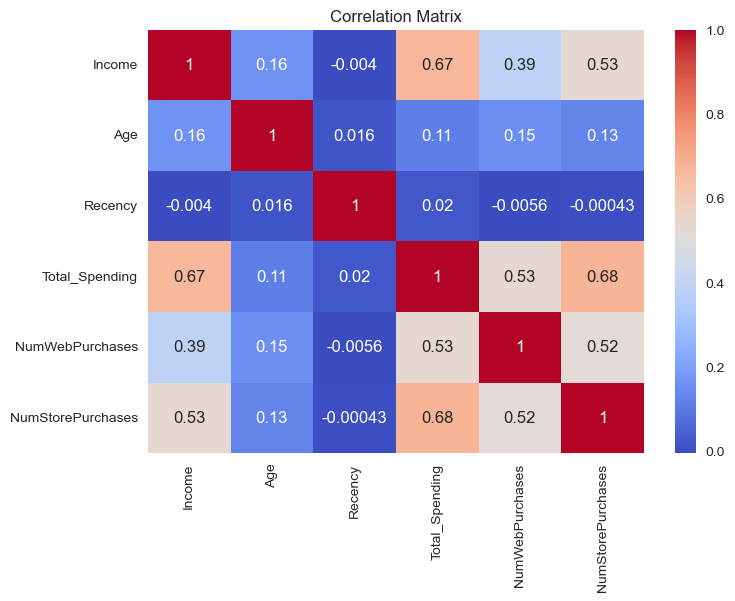

In [34]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [35]:
pivot_income = df.pivot_table(values = "Income", index = "Education", columns= "Marital_Status", aggfunc= "mean")

In [36]:
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


In [37]:
group1 = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending= False)

In [38]:
group1

Education
PhD           676.733888
Graduation    621.686380
Master        609.767123
2n Cycle      494.930000
Basic          81.796296
Name: Total_Spending, dtype: float64

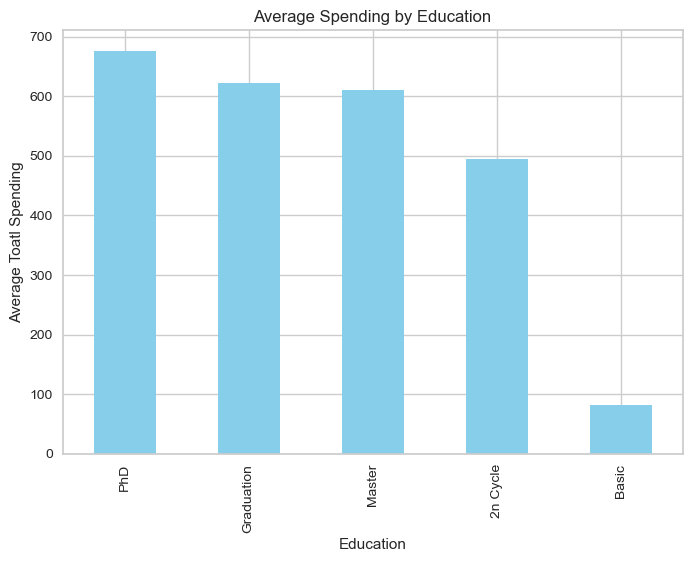

In [39]:
group1.plot(kind="bar", color = "skyblue")
plt.title("Average Spending by Education")
plt.ylabel("Average Toatl Spending")
plt.show()

In [40]:
df["AcceptedAny"]= df[["AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5","Response"]].sum(axis = 1)

In [41]:
df["AcceptedAny"].unique()

array([1, 0, 3, 2, 4, 5])

In [42]:
df["AcceptedAny"] = df["AcceptedAny"].apply(lambda x: 1 if x > 0 else 0)

In [43]:
df["AcceptedAny"].unique()

array([1, 0])

In [44]:
group2 = df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending= False)

In [45]:
group2

Marital_Status
Absurd      0.500000
YOLO        0.500000
Widow       0.342105
Alone       0.333333
Single      0.312102
Divorced    0.297414
Married     0.252042
Together    0.251309
Name: AcceptedAny, dtype: float64

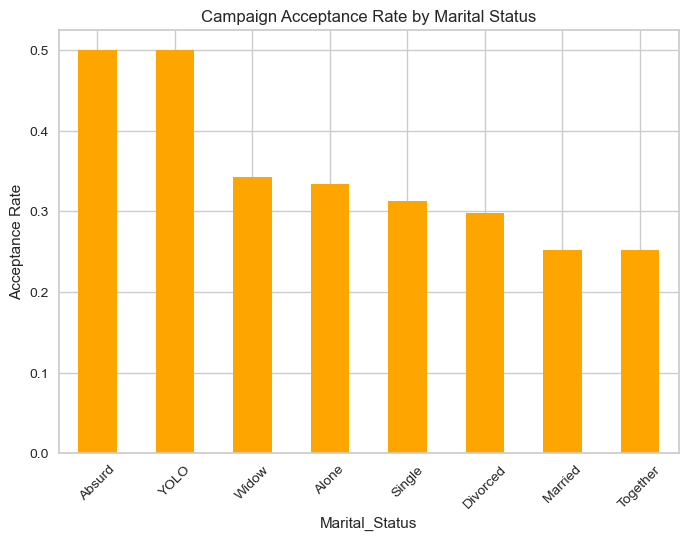

In [46]:
group2.plot(kind="bar", color = "orange")
plt.title("Campaign Acceptance Rate by Marital Status")
plt.ylabel("Acceptance Rate")
plt.xticks(rotation = 45)
plt.show()

In [47]:
bins = [18,30,40,50 ,60,70,90]

In [48]:
bins = [18, 30, 40, 50, 60, 70, 90]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']


df['AgeGroup'] = pd.cut(df['Age'], bins = bins, labels = labels)
df['AgeGroup']

0       60-69
1         70+
2       50-59
3       40-49
4       40-49
        ...  
2235    50-59
2236      70+
2237    40-49
2238    60-69
2239      70+
Name: AgeGroup, Length: 2216, dtype: category
Categories (6, object): ['18-29' < '30-39' < '40-49' < '50-59' < '60-69' < '70+']

In [49]:
group4 = df.groupby('AgeGroup')['Income'].mean()
group4

C:\Users\sim\AppData\Local\Temp\ipykernel_21508\414252599.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group4 = df.groupby('AgeGroup')['Income'].mean()


AgeGroup
18-29    46658.000000
30-39    46283.028302
40-49    49224.877034
50-59    50812.913303
60-69    56200.827887
70+      58944.316294
Name: Income, dtype: float64

C:\Users\sim\AppData\Local\Temp\ipykernel_21508\3150736940.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(group4, kind = 'bar', palette = 'RdYlGn', edgecolor = 'black')


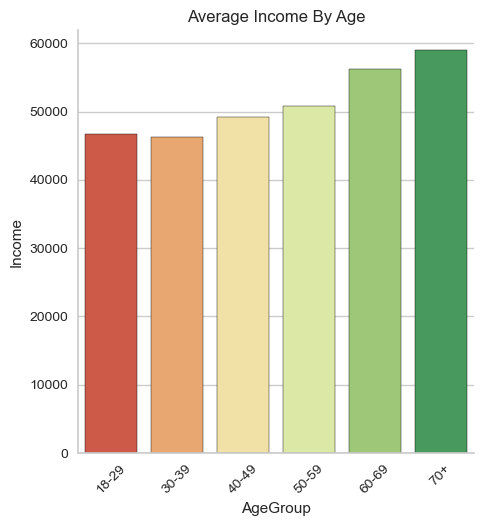

In [50]:
sns.catplot(group4, kind = 'bar', palette = 'RdYlGn', edgecolor = 'black')
plt.title('Average Income By Age')
plt.ylabel('Income')
plt.xticks(rotation = 45)
plt.show()

In [51]:
features = ['Age', 'Income', 'Total_Spending', 'NumWebPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']

In [52]:
X=df[features].copy()

In [53]:
X

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
0,68,58138.0,1617,8,4,7
1,71,46344.0,27,1,2,5
2,60,71613.0,776,8,10,4
3,41,26646.0,53,2,4,6
4,44,58293.0,422,5,6,5
...,...,...,...,...,...,...
2235,58,61223.0,1341,9,4,5
2236,79,64014.0,444,8,5,7
2237,44,56981.0,1241,2,13,6
2238,69,69245.0,843,6,10,3


In [54]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [55]:
wcss = []
Silhouette_score = []


for i in range(2, 16):
    kmeans = KMeans(n_clusters = i, random_state = 42)
    cluster_labels = kmeans.fit_predict(X_scaled)

    wcss.append(kmeans.inertia_)
    sil_score = silhouette_score(X_scaled, cluster_labels)

    Silhouette_score.append(sil_score)

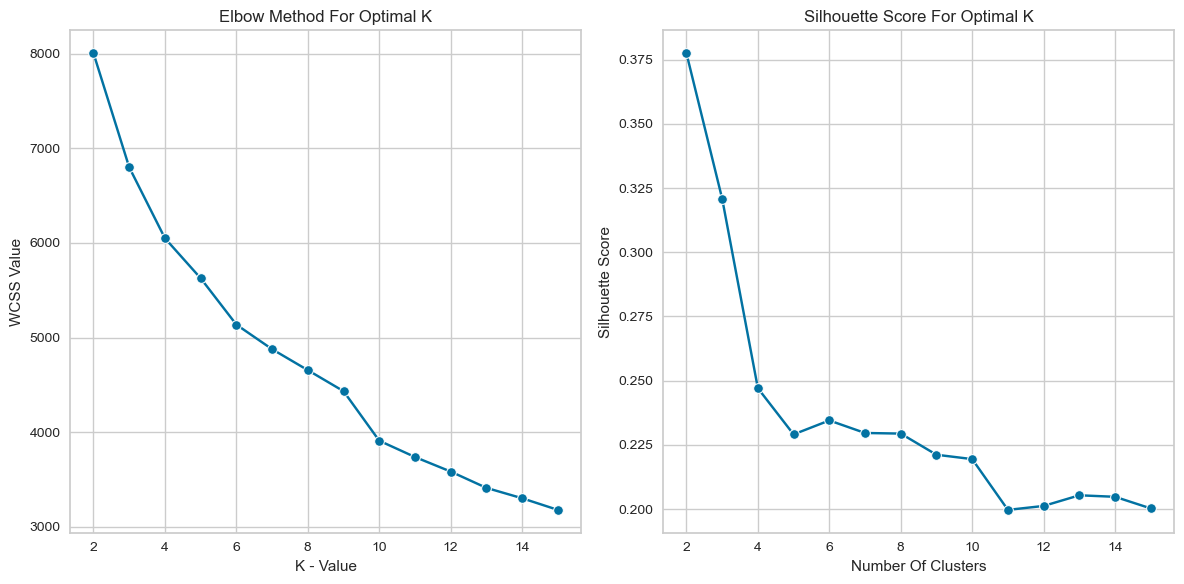

In [56]:
plt.figure(figsize = (12,6))
plt.subplot(121)
sns.lineplot(x = np.arange(2, 16), y = wcss, marker = 'o')
plt.title('Elbow Method For Optimal K')
plt.xlabel('K - Value')
plt.ylabel('WCSS Value')
plt.grid(True)

plt.subplot(122)
sns.lineplot(x = np.arange(2,16), y = Silhouette_score, marker = 'o')
plt.title('Silhouette Score For Optimal K')
plt.xlabel('Number Of Clusters')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.grid(True)
plt.show()

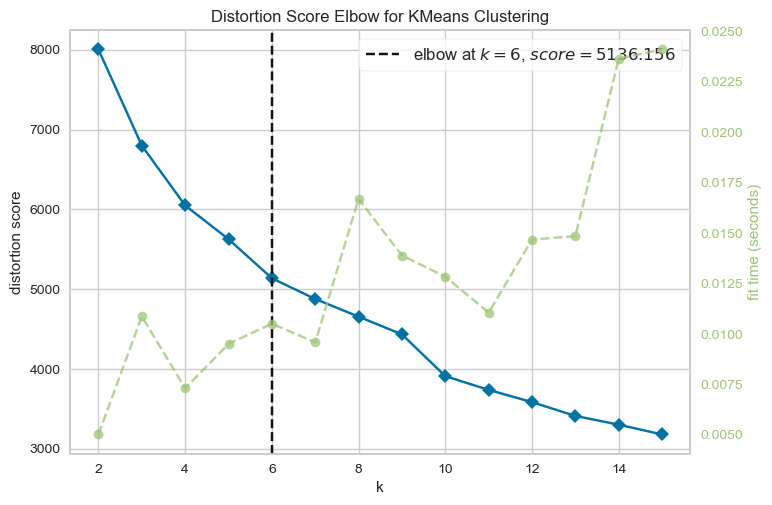

np.int64(6)

In [57]:
kmeans = KMeans(random_state = 42)
elbow = KElbowVisualizer(kmeans, k = (2, 16))
elbow.fit(X_scaled)
elbow.show(block = True)
elbow.elbow_value_

In [58]:
kmeans = KMeans(n_clusters = 5, random_state = 42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [59]:
df.head(3)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup,Cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,11,1,68,0,1617,4992,1,60-69,3
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,3,11,0,71,2,27,4442,0,70+,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,3,11,0,60,0,776,4641,0,50-59,1


In [60]:
cluster_summary = df.groupby('Cluster')[features].mean()

In [61]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
Cluster,,,,,,
0,47.348597,30881.152142,92.296898,2.093058,3.032496,6.976366
1,61.141509,67544.707547,1118.827044,6.364780,11.097484,4.616352
2,66.218673,42522.093366,157.491400,2.292383,3.914005,5.353808
3,59.117333,56367.442667,722.898667,7.472000,6.290667,6.546667
4,54.387244,79612.457859,1348.111617,4.275626,7.564920,2.191344


In [62]:
df['Cluster'].value_counts()

Cluster
0    677
4    439
2    407
3    375
1    318
Name: count, dtype: int64

In [63]:
pca = PCA(n_components = 2)
pca_data = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_data[:, 0], pca_data[:, 1]

In [64]:
pca_data

array([[ 1.1051798 ,  1.63021086],
       [-1.3340086 , -0.2097081 ],
       [ 1.88841354,  0.63959163],
       ...,
       [ 1.1427021 , -0.66746009],
       [ 1.89843476,  0.30996359],
       [-0.8395238 ,  0.72707899]], shape=(2216, 2))

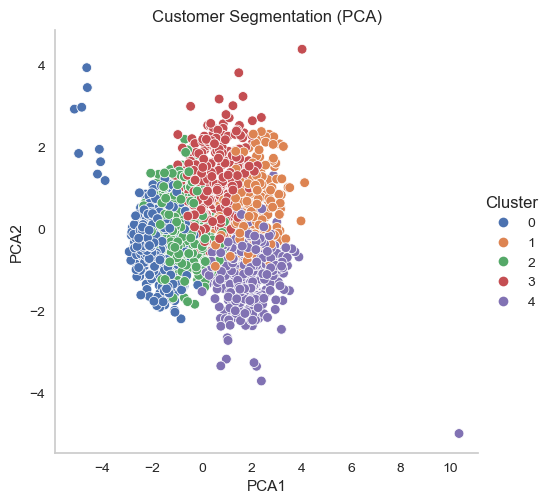

In [65]:
sns.relplot(data = df, x = 'PCA1', y = 'PCA2', hue = 'Cluster', palette = 'deep')
plt.title('Customer Segmentation (PCA)')
plt.grid(False)
plt.show()

In [66]:
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth
Cluster,,,,,,
0,47.348597,30881.152142,92.296898,2.093058,3.032496,6.976366
1,61.141509,67544.707547,1118.827044,6.364780,11.097484,4.616352
2,66.218673,42522.093366,157.491400,2.292383,3.914005,5.353808
3,59.117333,56367.442667,722.898667,7.472000,6.290667,6.546667
4,54.387244,79612.457859,1348.111617,4.275626,7.564920,2.191344


In [67]:
import joblib

joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']